# Synthetic Simulation of UAS Detection

## The Core IMM-EKF Engine

In [11]:
import numpy as np
from scipy.stats import chi2, multivariate_normal

class ThreatTracker_IMMEKF:
    def __init__(self, dt: float):
        self.dt = dt

        # 1. Filter Hyperparameters (From Manuscript Section 4.1)
        self.Pi = np.array(
            [[0.95, 0.05],
             [0.05, 0.95]]
        )

        # Initial Mode Probabilities: [mu_CV, mu_CT]
        self.mu = np.array([0.8, 0.2])

        # Nominal Evasive Turn Rate (rad/s) for Class 1/2 sUAS
        self.omega = 0.35

        # Process Noise Densities
        self.q_cv = 0.3
        self.q_ct = 0.8

        # Measurement Noise Covariance (1.0m^2, (0.005rad)^2, (0.005rad)^2)
        self.R = np.diag([1.0, 0.005**2, 0.005**2])

        # Mahalanobis Gate Threshold (99% confidence, 2-DOF)
        self.gamma = chi2.ppf(0.99, df=2) # ~9.21

        # 2. State Initialization: [x, y, z, x_dot, y_dot, z_dot]^T
        self.x_cv = np.zeros((6, 1))
        self.x_ct = np.zeros((6, 1))
        self.x_fused = np.zeros((6, 1))

        # Covariance Initialization
        self.P_cv = np.eye(6) * 10.0
        self.P_ct = np.eye(6) * 10.0
        self.P_fused = np.eye(6) * 10.0

    def _get_F_CV(self):
        """Constant Velocity State Transition Matrix"""
        F = np.eye(6)
        F[0, 3] = self.dt
        F[1, 4] = self.dt
        F[2, 5] = self.dt
        return F

    def _get_F_CT(self):
        """Coordinated Turn State Transition Matrix"""
        F = np.eye(6)
        wt = self.omega * self.dt

        F[0, 3] = np.sin(wt) / self.omega
        F[0, 4] = -(1 - np.cos(wt)) / self.omega
        F[1, 3] = (1 - np.cos(wt)) / self.omega
        F[1, 4] = np.sin(wt) / self.omega
        F[2, 5] = self.dt

        F[3, 3] = np.cos(wt)
        F[3, 4] = -np.sin(wt)
        F[4, 3] = np.sin(wt)
        F[4, 4] = np.cos(wt)
        return F

    def _get_process_noise(self, q):
        """Discrete Process Noise Matrix (Simplified strictly for position/velocity)"""
        G = np.array([
            [0.5 * self.dt**2, 0, 0],
            [0, 0.5 * self.dt**2, 0],
            [0, 0, 0.5 * self.dt**2],
            [self.dt, 0, 0],
            [0, self.dt, 0],
            [0, 0, self.dt]
        ])
        return G @ G.T * q

    def _measurement_function(self, x):
        """Non-linear mapping from Cartesian to Spherical (r, theta, phi)"""
        r = np.sqrt(x[0,0]**2 + x[1,0]**2 + x[2,0]**2)
        theta = np.arctan2(x[1,0], x[0,0])

        # Epsilon added to prevent division by zero
        eps = 1e-8
        xy_dist = np.maximum(np.sqrt(x[0,0]**2 + x[1,0]**2 + x[2,0]**2), eps)
        phi = np.arcsin(-x[2,0] / xy_dist)

        return np.array([[r], [theta], [phi]])

    def _measurement_jacobian(self, x):
        """Analytical Jacobian H_k evaluated at current state"""
        px, py, pz = x[0,0], x[1,0], x[2,0]
        r_sq = px**2 + py**2 + pz**2
        r = np.sqrt(r_sq)
        xy_sq = px**2 + py**2
        xy = np.sqrt(xy_sq)

        H = np.zeros((3, 6))
        if r_sq > 1e-8 and xy_sq > 1e-8:
            # dr/dx
            H[0, 0:3] = [px/r, py/r, pz/r]
            # dtheta/dx
            H[1, 0:2] = [-py/xy_sq, px/xy_sq]
            # dphi/dx
            H[2, 0:3] = [(px*pz)/(r_sq*xy), (py*pz)/(r_sq*xy), -xy/r_sq]
        return H

    def step(self, z_measured):
        """Executes one full cycle of the IMM-EKF algorithm"""

        # 1. Mixing Probabilities
        c = self.Pi.T @ self.mu
        mu_mix = (self.Pi * self.mu[:, None]) / c

        x_mix_cv = mu_mix[0,0] * self.x_cv + mu_mix[1,0] * self.x_ct
        x_mix_ct = mu_mix[0,1] * self.x_cv + mu_mix[1,1] * self.x_ct

        # 2. Prediction Step
        F_cv = self._get_F_CV()
        F_ct = self._get_F_CT()

        x_pred_cv = F_cv @ x_mix_cv
        x_pred_ct = F_ct @ x_mix_ct

        P_pred_cv = F_cv @ self.P_cv @ F_cv.T + self._get_process_noise(self.q_cv)
        P_pred_ct = F_ct @ self.P_ct @ F_ct.T + self._get_process_noise(self.q_ct)

        # 3. Update Step
        models = [(x_pred_cv, P_pred_cv), (x_pred_ct, P_pred_ct)]
        likelihoods = np.zeros(2)

        for i, (x_pred, P_pred) in enumerate(models):
            H = self._measurement_jacobian(x_pred)
            y_res = z_measured - self._measurement_function(x_pred)

            # Normalize angles
            y_res[1,0] = (y_res[1,0] + np.pi) % (2 * np.pi) - np.pi
            y_res[2,0] = (y_res[2,0] + np.pi) % (2 * np.pi) - np.pi

            S = H @ P_pred @ H.T + self.R
            K = P_pred @ H.T @ np.linalg.inv(S)

            if i == 0:
                self.x_cv = x_pred + K @ y_res
                self.P_cv = (np.eye(6) - K @ H) @ P_pred
            else:
                self.x_ct = x_pred + K @ y_res
                self.P_ct = (np.eye(6) - K @ H) @ P_pred

            try:
                likelihoods[i] = multivariate_normal.pdf(y_res.flatten(), mean=np.zeros(3), cov=S)
            except np.linalg.LinAlgError:
                likelihoods[i] = 1e-9

        # 4. Mode Probability Update
        self.mu = c * likelihoods
        self.mu /= np.sum(self.mu)

        # 5. Output Fusion
        self.x_fused = self.mu[0] * self.x_cv + self.mu[1] * self.x_ct
        self.P_fused = self.mu[0] * (self.P_cv + (self.x_cv - self.x_fused) @ (self.x_cv - self.x_fused).T) + \
                       self.mu[1] * (self.P_ct + (self.x_ct - self.x_fused) @ (self.x_ct - self.x_fused).T)

        return self.x_fused, self.mu

## The Synthetic Simulation

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def generate_evasive_trajectory(num_steps=400, dt=0.1):
    """
    Generates a synthetic sUAS flight path in NED coordinates.
    Includes a cruising phase, an evasive banking turn, and an occlusion window.
    """
    time = np.arange(0, num_steps * dt, dt)

    # Ground Truth Arrays
    x_true = np.zeros(num_steps)
    y_true = np.zeros(num_steps)
    z_true = np.zeros(num_steps)

    # Sensor Measurement Arrays (r, theta, phi)
    z_measured = np.zeros((3, num_steps))

    # Flight Parameters
    velocity = 15.0 # m/s
    turn_rate = 0.35 # rad/s (Matches omega in the paper)

    # Initial Position (NED)
    x, y, z = 100.0, 50.0, -30.0
    heading = 0.0 # Moving North

    # 3-Second Occlusion Window (t=22s to t=25s)
    occlusion_start_idx = int(22.0 / dt)
    occlusion_end_idx = int(25.0 / dt)

    for i in range(num_steps):
        t = time[i]

        # Evasive Maneuver: Turn between t=15s and t=28s
        if 15.0 <= t <= 28.0:
            heading += turn_rate * dt

        # Kinematic Update (CV/CT hybrid)
        x += velocity * np.cos(heading) * dt
        y += velocity * np.sin(heading) * dt
        z += 0.0 # Constant altitude for simplicity

        x_true[i] = x
        y_true[i] = y
        z_true[i] = z

        # Ideal Spherical Measurements
        r_true = np.sqrt(x**2 + y**2 + z**2)
        theta_true = np.arctan2(y, x)
        phi_true = np.arcsin(-z / np.maximum(r_true, 1e-8))

        # Add Sensor Noise (Simulating LRDDv3 optical/laser noise)
        r_noisy = r_true + np.random.normal(0, 1.0)
        theta_noisy = theta_true + np.random.normal(0, 0.005)
        phi_noisy = phi_true + np.random.normal(0, 0.005)

        # Simulate Total Optical Occlusion (Sensors drop the track)
        if occlusion_start_idx <= i <= occlusion_end_idx:
            # Send NaNs or zeros to simulate dropout
            z_measured[:, i] = [np.nan, np.nan, np.nan]
        else:
            z_measured[:, i] = [r_noisy, theta_noisy, phi_noisy]

    return time, x_true, y_true, z_true, z_measured

# Generate the data
time_sim, x_true, y_true, z_true, z_measured = generate_evasive_trajectory()

print(f"Generated {len(time_sim)} telemetry steps.")
print("Trajectory includes a 3-second optical occlusion and an evasive turn.")

Generated 400 telemetry steps.
Trajectory includes a 3-second optical occlusion and an evasive turn.


## The Execution & Visualization Loop

Initiating IMM-EKF Tracking Sequence...
Tracking Complete. Max Occlusion Error: 21.701 m


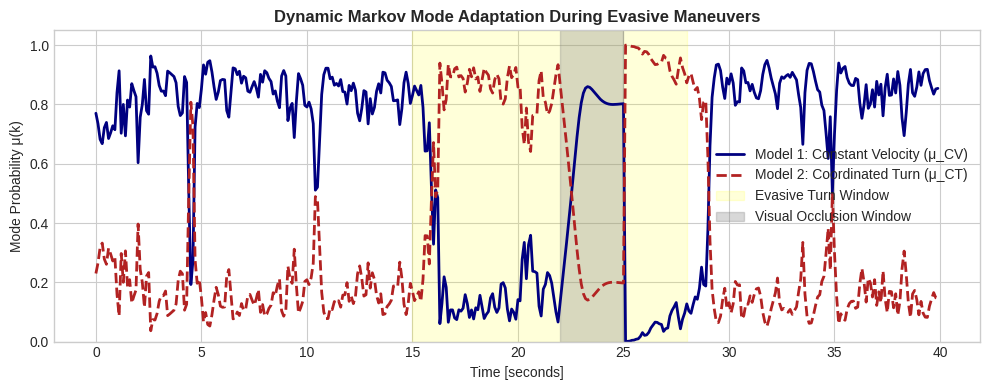

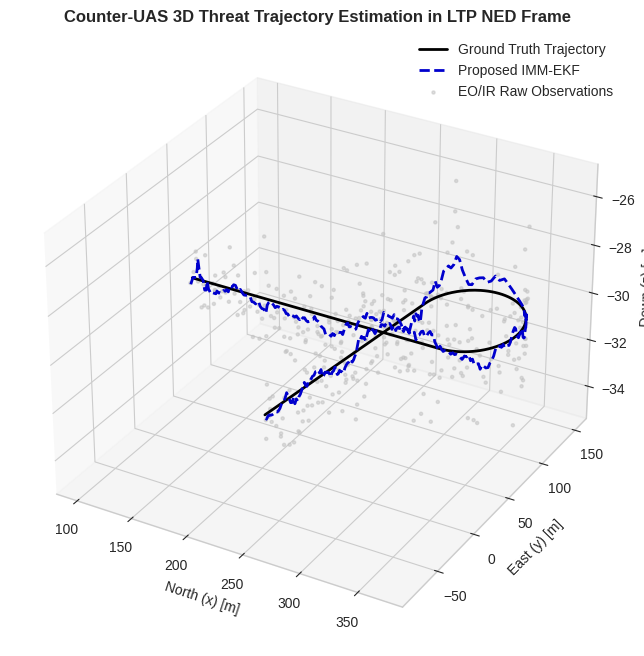

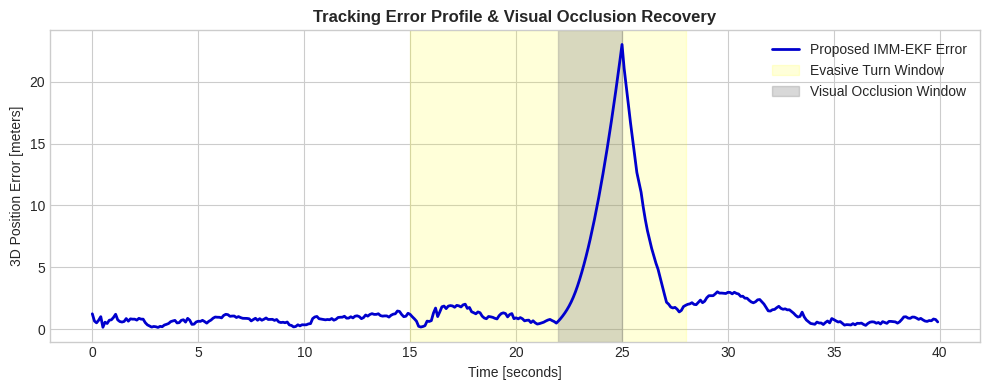

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Initialize the IMM-EKF Engine
dt = 0.1
tracker = ThreatTracker_IMMEKF(dt=dt)

# Initialize the state close to the first ground-truth point
# (In the field, this is provided by the first validated radar/optical hit)
tracker.x_cv[0:3, 0] = [x_true[0], y_true[0], z_true[0]]
tracker.x_ct[0:3, 0] = [x_true[0], y_true[0], z_true[0]]
tracker.x_cv[3:5, 0] = [15.0, 0.0] # Initial velocity estimate
tracker.x_ct[3:5, 0] = [15.0, 0.0]

# Storage arrays for plotting
est_x, est_y, est_z = [], [], []
mu_cv, mu_ct = [], []
position_errors = []

print("Initiating IMM-EKF Tracking Sequence...")

# 2. Main Tracking Loop
for i in range(len(time_sim)):
    z_k = z_measured[:, i:i+1] # Keep as (3, 1) column vector

    # Handle the 3-Second Optical Occlusion (NLOS)
    if np.isnan(z_k[0, 0]):
        # Dead Reckoning: If sensors drop, we feed the filter its own predicted
        # measurement to force an innovation of zero. This skips the measurement
        # update, allowing the covariance (uncertainty) to grow naturally while
        # the kinematic model continues flying the drone mathematically.
        pred_measurement = tracker._measurement_function(tracker.x_fused)
        x_fused, mu = tracker.step(pred_measurement)
    else:
        # Normal measurement update
        x_fused, mu = tracker.step(z_k)

    # Log states
    est_x.append(x_fused[0, 0])
    est_y.append(x_fused[1, 0])
    est_z.append(x_fused[2, 0])
    mu_cv.append(mu[0])
    mu_ct.append(mu[1])

    # Calculate instantaneous 3D error
    err = np.sqrt((x_fused[0,0] - x_true[i])**2 +
                  (x_fused[1,0] - y_true[i])**2 +
                  (x_fused[2,0] - z_true[i])**2)
    position_errors.append(err)

print(f"Tracking Complete. Max Occlusion Error: {max(position_errors[220:250]):.3f} m")

# 3. Generate Manuscript-Ready Visualizations
plt.style.use('seaborn-v0_8-whitegrid')

# --- FIGURE 1: Mode Probabilities ---
fig1, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(time_sim, mu_cv, label='Model 1: Constant Velocity (μ_CV)', color='navy', linewidth=2)
ax1.plot(time_sim, mu_ct, label='Model 2: Coordinated Turn (μ_CT)', color='firebrick', linestyle='--', linewidth=2)
ax1.axvspan(15, 28, color='yellow', alpha=0.15, label='Evasive Turn Window')
ax1.axvspan(22, 25, color='gray', alpha=0.3, label='Visual Occlusion Window')
ax1.set_title('Dynamic Markov Mode Adaptation During Evasive Maneuvers', fontsize=12, fontweight='bold')
ax1.set_xlabel('Time [seconds]')
ax1.set_ylabel('Mode Probability μ(k)')
ax1.set_ylim([0, 1.05])
ax1.legend(loc='center right')
plt.tight_layout()

# --- FIGURE 2: 3D Trajectory Estimation ---
fig2 = plt.figure(figsize=(10, 8))
ax2 = fig2.add_subplot(111, projection='3d')
ax2.plot(x_true, y_true, z_true, label='Ground Truth Trajectory', color='black', linewidth=2)
ax2.plot(est_x, est_y, est_z, label='Proposed IMM-EKF', color='mediumblue', linestyle='--', linewidth=2)
# Reconstruct noisy observations for plotting purely to show the sensor scatter
obs_x = z_measured[0,:] * np.cos(z_measured[2,:]) * np.cos(z_measured[1,:])
obs_y = z_measured[0,:] * np.cos(z_measured[2,:]) * np.sin(z_measured[1,:])
obs_z = -z_measured[0,:] * np.sin(z_measured[2,:])
ax2.scatter(obs_x, obs_y, obs_z, label='EO/IR Raw Observations', color='silver', s=5, alpha=0.5)

ax2.set_title('Counter-UAS 3D Threat Trajectory Estimation in LTP NED Frame', fontsize=12, fontweight='bold')
ax2.set_xlabel('North (x) [m]')
ax2.set_ylabel('East (y) [m]')
ax2.set_zlabel('Down (z) [m]')
ax2.legend()

# --- FIGURE 3: Position Error Profile ---
fig3, ax3 = plt.subplots(figsize=(10, 4))
ax3.plot(time_sim, position_errors, label='Proposed IMM-EKF Error', color='mediumblue', linewidth=2)
ax3.axvspan(15, 28, color='yellow', alpha=0.15, label='Evasive Turn Window')
ax3.axvspan(22, 25, color='gray', alpha=0.3, label='Visual Occlusion Window')
ax3.set_title('Tracking Error Profile & Visual Occlusion Recovery', fontsize=12, fontweight='bold')
ax3.set_xlabel('Time [seconds]')
ax3.set_ylabel('3D Position Error [meters]')
ax3.legend(loc='upper right')
plt.tight_layout()

plt.show()